# SVM 

## What was missing
- Gradient update logic for hinge-loss training loop
- Prediction from learned `w` and `b`
- Accuracy computation
- Decision boundary and margin visualization

In [1]:
# Core training update completed in svm_finished.py
import numpy as np

def svm_step(x_i, y_i, w, b, lr=0.01, regu_lambda=0.01):
    condition = y_i * (np.dot(x_i, w) + b) >= 1
    if condition:
        dw = 2 * regu_lambda * w
        db = 0
    else:
        dw = 2 * regu_lambda * w - np.dot(x_i, y_i)
        db = -y_i
    w = w - lr * dw
    b = b - lr * db
    return w, b

w: [-0.84278195 -0.35120679]
b: 0.26000000000000006
Accuracy of SVM: 100.0 %


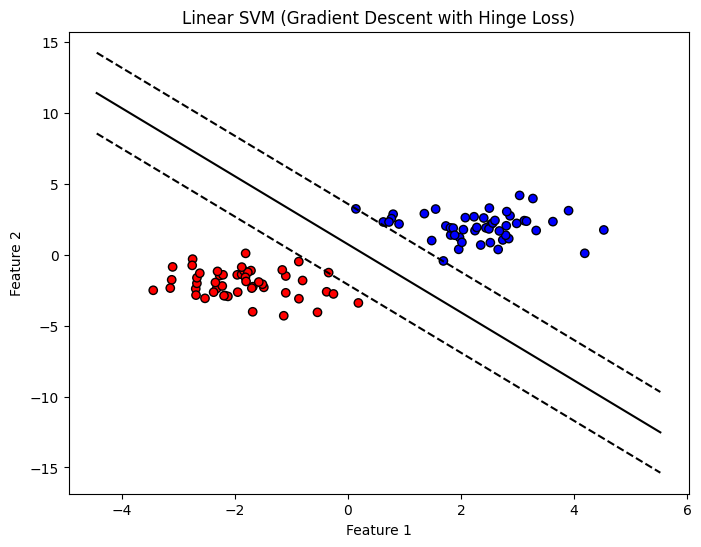

In [2]:
# End-to-end completed logic (same core flow as svm_finished.py)
import numpy as np
import matplotlib.pyplot as plt

lr = 0.01
regu_lambda = 0.01
n_iters = 500

np.random.seed(1)
X1 = np.random.randn(50, 2) + np.array([-2, -2])
X2 = np.random.randn(50, 2) + np.array([2, 2])
X = np.vstack((X1, X2))
y = np.hstack((np.ones(50), -1 * np.ones(50)))

w = np.zeros(X.shape[1])
b = 0

for _ in range(n_iters):
    for idx, x_i in enumerate(X):
        condition = y[idx] * (np.dot(x_i, w) + b) >= 1
        if condition:
            dw = 2 * regu_lambda * w
            db = 0
        else:
            dw = 2 * regu_lambda * w - np.dot(x_i, y[idx])
            db = -y[idx]
        w = w - lr * dw
        b = b - lr * db

preds = np.sign(np.dot(X, w) + b)
preds[preds == 0] = 1
accuracy = np.mean(preds == y) * 100
print('w:', w)
print('b:', b)
print('Accuracy of SVM:', accuracy, '%')

def get_hyperplane_value(x, w, b, offset):
    return (-w[0] * x - b + offset) / w[1]

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')

x0_1 = np.min(X[:, 0]) - 1
x0_2 = np.max(X[:, 0]) + 1

x1_1 = get_hyperplane_value(x0_1, w, b, 0)
x1_2 = get_hyperplane_value(x0_2, w, b, 0)
x1_1_m = get_hyperplane_value(x0_1, w, b, -1)
x1_2_m = get_hyperplane_value(x0_2, w, b, -1)
x1_1_p = get_hyperplane_value(x0_1, w, b, 1)
x1_2_p = get_hyperplane_value(x0_2, w, b, 1)

plt.plot([x0_1, x0_2], [x1_1, x1_2], 'k-')
plt.plot([x0_1, x0_2], [x1_1_m, x1_2_m], 'k--')
plt.plot([x0_1, x0_2], [x1_1_p, x1_2_p], 'k--')

plt.title('Linear SVM (Gradient Descent with Hinge Loss)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()